# Stage 4a — Generalised LoRA Fine-Tuning
## Model: `mistralai/Mistral-7B-Instruct-v0.3` | Dataset: CB1 (6-Class Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**This stage:** Both multiplicative AND additive components active simultaneously  
**Seed:** 42 | **Split:** 75/25 stratified | **Primary metric:** Macro F1 | **Secondary:** MCC

---

## README — Before Step 1

### Mistral-7B-specific facts

| Property | Value |
|---|---|
| **HF token** | Not required — model is public |
| **dtype** | `bfloat16` |
| **Train batch** | 8 (CB1, A100 40GB) |
| **Eval batch** | 16 |
| **PEFT layers** | 128 |
| **No system role** | Mistral-7B-Instruct-v0.3 supports system messages — pad token = eos token |

### Mistral rank pattern — critical watch point

Mistral is the only model with an **inverse rank pattern** in Stage 2 (F1 decreases as r increases):

| Stage | r=4 | r=8 | r=16 | r=32 | Pattern |
|---|---|---|---|---|---|
| **Stage 2** (additive) | 0.8949 ★ | 0.8888 | 0.8808 | 0.8753 | ↓ monotonic — UNIQUE |
| **Stage 3** (multiplicative) | 0.8961 | 0.8984 ★ | **0.7616 🔴COLLAPSE** | 0.8873 | anomalous |
| **Stage 4** (generalised) | ? | ? | ? | ? | AB may stabilise r=16 |

**Stage 3 r=16 collapse (F1=0.7616, stability=0.624)** — severe training instability, not capacity failure.  
The AB additive component in Stage 4 may stabilise this — if gradients through UV diverge, AB provides a compensating path.  
**Either outcome is publishable:**
- Stabilises → generalised LoRA is more robust than multiplicative alone
- Collapses again → Mistral r=16 instability is architectural, independent of adaptation type

### Effective rank bug fix (from Stage 4 Llama-3B)

Stage 4 Llama-3B reported `eff_rank_Wf = 0.00` because `named_modules()` walk used  
`name.split('.')` which can mis-navigate the parent. The fix (from Stage 3 Mistral) is:
```python
parts = name.rsplit('.', 1)   # safe split — used in Stage 3 Mistral, now adopted for Stage 4
```
This notebook includes the corrected `calculate_effective_rank_generalised()` and `apply_generalised_lora_over_peft()`.

### Stage 2/3 references

| Stage | r=4 | r=8 | r=16 | r=32 | Best | Eff.Rank |
|---|---|---|---|---|---|---|
| S2 Mistral CB1 | 0.8949 ★ | 0.8888 | 0.8808 | 0.8753 | r=4 | ~2523 |
| S3 Mistral CB1 | 0.8961 | 0.8984 ★ | 0.7616 🔴 | 0.8873 | r=8 | 2516–2523 ⚠ varies |
| S4 Llama-3B (ref) | 0.8896 | 0.8945 | 0.8981 ★ | 0.8967 | r=16 | bug — TBD |

**Target to beat:** Gemma-2-9B Stage 2 r=32: F1=0.9010 (overall CB1 champion)


---
## Step 1: Install Required Libraries

**Known errors and fixes:**

| Error | Cause | Fix |
|---|---|---|
| `AttributeError: torch has no float8_e8m0fnu` → `ModuleNotFoundError: TrainingArguments` | `transformers>=4.52` requires torch>=2.6; Colab ships 2.5.x | Pin `transformers<4.52` |
| `ImportError: cannot import name '_center'` | `numpy>=2.1` | Pin `numpy<2.1` |
| `ImportError: VideoReader` | `torchvision` mismatch | Pin `torchvision==0.20.1` |

**After running: Runtime → Restart Runtime, then run from Step 2 onwards. Do NOT re-run Step 1.**


In [1]:
# ── Install with pinned versions — compatible with Colab torch 2.5.x ───────────
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

print("✓ Installation complete.")
print()
print("=" * 60)
print("  ACTION REQUIRED: Restart the Colab runtime now.")
print("  Runtime → Restart Runtime  (or Ctrl+M .)")
print("  After restart: run from Step 2 onwards.")
print("  Do NOT re-run Step 1 after restart.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 137.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2: Import Libraries and Initial Setup

**Mistral-specific:** No HF token required — `mistralai/Mistral-7B-Instruct-v0.3` is public.  
Everything else identical to Stage 4 Llama-3B.


In [1]:
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)

from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb

from google.colab import drive, userdata

def set_all_seeds(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# Mistral-7B-Instruct-v0.3 does NOT require an HF token
HF_TOKEN = None
print("✓ HF token: not required for Mistral-7B-Instruct-v0.3.")

drive.mount('/content/drive')
print("✓ Google Drive mounted.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HF token: not required for Mistral-7B-Instruct-v0.3.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Mistral-specific changes from Llama-3B Stage 4:**
- `MODEL_NAME` → `mistralai/Mistral-7B-Instruct-v0.3`
- `TRAIN_BATCH_SIZE` = 8 (7B model requires smaller batch on A100 40GB)
- `EVAL_BATCH_SIZE` = 16
- `OUTPUT_DIR` → `CB1_GeneralisedLoRA_Mistral7B`
- No HF token needed


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION — Stage 4a: Generalised LoRA | CB1 | Mistral-7B
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME   = "mistralai/Mistral-7B-Instruct-v0.3"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16        # Always = LORA_RANK → scaling = 1.0
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 32]   # r=16 from Step 12 — NOT repeated

NUM_EPOCHS         = 1
LEARNING_RATE      = 2e-4
TRAIN_BATCH_SIZE   = 8      # Mistral-7B CB1 safe batch on A100 40GB
EVAL_BATCH_SIZE    = 16
WEIGHT_DECAY       = 0.01
EVAL_STEPS         = 200
LOGGING_STEPS      = 50
OUTPUT_DIR         = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying':   0, 'gender':  1, 'religion': 2,
    'ethnicity': 3, 'age': 4, 'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 4a — Generalised LoRA")
print(f"  Formula  : Wf = W(I + UV) + AB   [both paths active]")
print(f"  Model    : {MODEL_NAME}")
print(f"  HF token : Not required")
print(f"  Batch    : train={TRAIN_BATCH_SIZE} | eval={EVAL_BATCH_SIZE}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Rank sweep (Step 13): {RANK_SWEEP}  [r=16 from Step 12 — not repeated]")
print()
print("  ── Stage references ──")
print("  S2 Mistral CB1 : r=4: 0.8949★ | r=8: 0.8888 | r=16: 0.8808 | r=32: 0.8753  ↓ inverse")
print("  S3 Mistral CB1 : r=4: 0.8961  | r=8: 0.8984★| r=16: 0.7616🔴| r=32: 0.8873  ⚠ collapse")
print("  S4 Llama-3B    : r=4: 0.8896  | r=8: 0.8945 | r=16: 0.8981★| r=32: 0.8967   ↑ then ↓")
print("  Overall target : Gemma-2-9B S2 r=32: F1=0.9010 ← must beat")


✓ Configuration loaded.
  Stage    : 4a — Generalised LoRA
  Formula  : Wf = W(I + UV) + AB   [both paths active]
  Model    : mistralai/Mistral-7B-Instruct-v0.3
  HF token : Not required
  Batch    : train=8 | eval=16
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Rank sweep (Step 13): [4, 8, 32]  [r=16 from Step 12 — not repeated]

  ── Stage references ──
  S2 Mistral CB1 : r=4: 0.8949★ | r=8: 0.8888 | r=16: 0.8808 | r=32: 0.8753  ↓ inverse
  S3 Mistral CB1 : r=4: 0.8961  | r=8: 0.8984★| r=16: 0.7616🔴| r=32: 0.8873  ⚠ collapse
  S4 Llama-3B    : r=4: 0.8896  | r=8: 0.8945 | r=16: 0.8981★| r=32: 0.8967   ↑ then ↓
  Overall target : Gemma-2-9B S2 r=32: F1=0.9010 ← must beat


---
## Step 4: Text Preprocessing

Identical to all prior stages — verbatim copy required for reproducible split.


In [3]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:   text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text

test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

Identical to all prior stages — same pipeline guarantees same post-cleaning dataset.


In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")
df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
print(f"[2] Columns renamed: {df.columns.tolist()}")
corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows → {len(df):,} remaining")
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")
text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[5] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts → {len(df):,} remaining")
unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
print(f"\n  Imbalance ratio : {counts.max()/counts.min():.2f}×")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Columns renamed: ['text', 'label']
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed 3,250 annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×


---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

Identical to all prior stages — seed=42, same test set across all stages.


In [5]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end         = min(start + 500, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df        = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df   = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE DETECTED: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN,
    random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"    ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed.

[3] Validation carved → Train: 29,703 | Val: 3,301 | Test: 10,330
    ✓ Protocol check: test = 23.8% (target: 25.0%)


---
## Step 7: Helper Functions — Class Weights

Identical to all prior stages.


In [6]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    counts       = df[label_col].value_counts()
    total        = len(df)
    n_classes    = len(LABEL_MAPPING)
    weights      = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights (inverse-frequency, normalised):")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank Computation — Generalised LoRA (FIXED)

**Bug fixed from Stage 4 Llama-3B:** `avg_eff_rank_Wf` reported 0.00 because the parent  
navigation used `name.split('.')` which could mis-navigate for nested module names.

**Fix adopted from Stage 3 Mistral:** use `name.rsplit('.', 1)` — splits only on the  
last dot, giving the correct `(parent_path, attr_name)` pair every time.

This fix is applied in **both** `calculate_effective_rank_generalised()` and  
`apply_generalised_lora_over_peft()` below.

SVD is computed on the full `Wf = W + W@(UV) + A@B` — NOT on the adapters alone.


In [7]:
def calculate_effective_rank_generalised(model: nn.Module,
                                           threshold_ratio: float = 1e-3) -> Dict[str, float]:
    """
    Compute effective rank of Wf = W(I + UV) + AB = W + W@(UV) + A@B.

    BUG FIX vs Stage 4 Llama-3B:
      parent navigation now uses name.rsplit('.', 1) — adopted from Stage 3 Mistral.
      The Llama-3B version used name.split('.') which could mis-navigate nested modules,
      causing 'No GeneralisedLoRALayer found' (all 112 layers skipped, Wf=0.00).

    SVD threshold: 0.1% of max singular value — consistent with Stages 2 and 3.
    Reports avg_eff_rank_Wf (primary), avg_eff_rank_UV, avg_eff_rank_AB (reference).
    """
    full_ranks = []
    uv_ranks   = []
    ab_ranks   = []
    per_layer  = []
    skipped    = 0

    for name, module in model.named_modules():
        # Use type name string check — robust across kernel restarts / class redefinitions
        if type(module).__name__ != 'GeneralisedLoRALayer':
            continue
        try:
            U  = module.lora_U.data.float()
            V  = module.lora_V.data.float()
            A  = module.lora_A.data.float()
            B  = module.lora_B.data.float()

            UV = U @ V    # (n × n)
            AB = A @ B    # (m × n)

            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)

            # Dequantise W from 4-bit NF4
            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0:
                    print(f"  ℹ First dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue

            # W is (out_features, in_features) = (m, n)
            # UV is (n, n), AB is (m, n)
            # Need W as (m, n) for W @ UV to work: (m,n) @ (n,n) = (m,n)
            if W.shape[0] == module.m and W.shape[1] == module.n:
                pass  # correct shape already
            elif W.shape[0] == module.n and W.shape[1] == module.m:
                W = W.T.contiguous()
            else:
                if skipped == 0:
                    print(f"  ℹ Shape mismatch: W={list(W.shape)}, m={module.m}, n={module.n}")
                skipped += 1; continue

            # Wf = W + W@(UV) + A@B
            Wf   = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0

            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})

        except Exception:
            skipped += 1; continue

    if skipped > 0:
        print(f"  ℹ {skipped} layers skipped during eff. rank computation")
    if not full_ranks:
        print("  ⚠ No GeneralisedLoRALayer found — check model structure")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks))   if uv_ranks   else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks))   if ab_ranks   else 0.0,
        "layer_count":     len(full_ranks),
        "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_generalised() defined.")
print("  Fix: type(module).__name__ check — robust vs isinstance() across restarts.")
print("  SVD on Wf = W + W@(UV) + A@B  (full generalised weight).")
print("  S2 ref Mistral: 2523.79  |  S3 ref Mistral: 2523.79 (constant ✓, r=16)")


✓ calculate_effective_rank_generalised() defined.
  Fix: type(module).__name__ check — robust vs isinstance() across restarts.
  SVD on Wf = W + W@(UV) + A@B  (full generalised weight).
  S2 ref Mistral: 2523.79  |  S3 ref Mistral: 2523.79 (constant ✓, r=16)


---
## Step 9: Evaluation Metrics

Identical to all prior stages — `compute_metrics()`, `evaluate_dataset()`, `make_predictions()`.


In [8]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true, y_pred, dataset_name) -> Dict[str, float]:
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(
        y_true, y_pred, labels=list(range(NUM_LABELS)),
        target_names=TARGET_NAMES, zero_division=0, digits=4))

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1,
            'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc}


def make_predictions(model, df_test, tokenizer, batch_size=32):
    model.eval()
    all_preds = []
    texts     = df_test['text'].tolist()
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[start:start+batch_size], padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt').to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    df_out = df_test.copy()
    df_out['predictions'] = all_preds
    return df_out


print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---
## Step 10: Stability System + Custom Trainer

Identical to Stage 4 Llama-3B. 2-panel stability plot (loss curve + val metrics).  
`plot_cross_stage_stability()` pre-populated with S2 and S3 Mistral values for Step 14.


In [9]:
import matplotlib.gridspec as gridspec

class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max() - arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 4', save_path: str = None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve')
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', alpha=0.6)
                ax2.fill_between(self.val_steps,
                                 [f1_mean-f1_std]*len(self.val_steps),
                                 [f1_mean+f1_std]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10,
                                 label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen')
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r and 'mcc' in self.val_metrics:
                mcc_vals = self.val_metrics['mcc']
                ax2_r.plot(self.val_steps, mcc_vals, 's--', color='darkorange',
                           linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2_r.set_ylabel('MCC', color='darkorange')
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
            lines1, labels1 = ax2.get_legend_handles_labels()
            lines2, labels2 = (ax2_r.get_legend_handles_labels() if ax2_r else ([], []))
            ax2.legend(lines1+lines2, labels1+labels2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics (F1 & MCC)')
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Stability plot saved → {save_path}")
        plt.show()


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    stages = list(stage_reports.keys())
    colors = ['#2E75B6', '#F4A261', '#1B998B', '#E63946'][:len(stages)]
    metrics_to_plot = [
        ('loss_cv_overall',  'Loss CV (overall)',   'lower = more stable'),
        ('loss_std_overall', 'Loss Std Dev',         'lower = more stable'),
        ('val_f1_std',       'Val F1 Std Dev',       'lower = more stable'),
        ('stability_score',  'Composite Stability',  'lower = more stable'),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    for ax, (key, title, subtitle) in zip(axes, metrics_to_plot):
        vals = [stage_reports[s].get(key, 0.0) for s in stages]
        ax.bar(range(len(stages)), vals, color=colors, alpha=0.85,
               edgecolor='white', linewidth=1.5, width=0.5)
        for i, v in enumerate(vals):
            ax.text(i, v + max(vals)*0.02, f'{v:.4f}', ha='center',
                    va='bottom', fontsize=9, fontweight='bold')
        if key == 'stability_score':
            ax.axhline(0.05,  color='green',  linestyle='--', linewidth=1.2, label='Very stable')
            ax.axhline(0.15,  color='orange', linestyle='--', linewidth=1.2, label='Acceptable')
            ax.legend(fontsize=8)
        ax.set_xticks(range(len(stages)))
        ax.set_xticklabels(stages, fontsize=9)
        ax.set_title(f'{title}\n({subtitle})')
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle(
        'Cross-Stage Stability — CB1 | Mistral-7B-Instruct-v0.3\n'
        'Stage 2: Wf=W+AB  |  Stage 3: Wf=W(I+UV)  |  Stage 4: Wf=W(I+UV)+AB',
        fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Cross-stage stability plot saved → {save_path}")
    plt.show()


class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (torch.tensor(class_weights, dtype=torch.float32)
                              if class_weights is not None else None)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = (nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
                   if self.class_weights is not None else nn.CrossEntropyLoss())
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


print("✓ StabilityCallback, plot_cross_stage_stability(), CustomTrainer defined.")


✓ StabilityCallback, plot_cross_stage_stability(), CustomTrainer defined.


---
## Step 11: Generalised LoRA Adapter + Training Function

**Two fixes applied vs Stage 4 Llama-3B:**

1. **Effective rank bug fix** — `type(module).__name__` check instead of `isinstance()`,  
   and `name.rsplit('.', 1)` parent navigation (from Stage 3 Mistral). Resolves `Wf=0.00`.

2. **`torch_dtype=` not `dtype=`** in `from_pretrained()` — stricter transformers version.

**Mistral-specific:**
- No HF token in `from_pretrained()`
- `TRAIN_BATCH_SIZE = 8` (7B model)
- `torch_dtype=torch.bfloat16`
- `warmup_steps=100`, `lr_scheduler_type='cosine'` (from Stage 3 Mistral — better convergence)


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# GeneralisedLoRALayer — Wf = W(I + UV) + AB
# ════════════════════════════════════════════════════════════════════════════

class GeneralisedLoRALayer(nn.Module):
    """
    Dual adapter: multiplicative (UV) + additive (AB).

    Forward: y = W·x + scaling·W·(U·(V·x)) + scaling·A·(B·x)
             base    mult. path               add. path

    Init: V=0 (UV=0), B=0 (AB=0) → Wf=W at start (safe).
    Scaling = alpha/rank = 1.0 always.
    Device fix: .to(x.device) in forward — adapter params init on CPU,
                x arrives on CUDA.
    """
    def __init__(self, base_layer: nn.Module, rank: int,
                 dropout: float = 0.05, alpha: int = None):
        super().__init__()
        self.rank    = rank
        self.alpha   = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank

        # Unwrap PEFT LoraLayer → actual Linear4bit
        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine in/out features from {type(inner)}")

        self.n     = n
        self.m     = m
        self.inner = inner

        # Determine device from inner layer — ensures params are on CUDA from the start.
        # CRITICAL FIX: creating params on CPU then using .to(dev) in forward() causes
        # gradient flow to break — optimizer holds CPU refs, gradients go to CUDA copies.
        # Stage 3 Mistral confirmed: params must be on same device as inner.weight.
        _dev = self.inner.weight.device

        # Multiplicative adapter (UV)
        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))   # (n × r)
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))   # (r × n) — zero init

        # Additive adapter (AB)
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))   # (m × r)
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))   # (r × n) — zero init

        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()

        for param in self.inner.parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Params are already on the correct device (initialised on inner.weight.device).
        # Do NOT use .to(x.device) — it creates copies that break gradient flow.
        # This matches Stage 3 Mistral's working pattern (self.lora_V.T directly).
        base_out = self.inner(x)           # W·x  (base path)
        x_drop   = self.dropout(x)

        # Multiplicative: W·(U·(V·x))
        lora_vx  = x_drop @ self.lora_V.T      # (..., r)
        lora_uvx = lora_vx @ self.lora_U.T     # (..., n)
        mult_out = self.inner(lora_uvx)         # (..., m)

        # Additive: A·(B·x)
        lora_bx  = x_drop @ self.lora_B.T      # (..., r)
        add_out  = lora_bx @ self.lora_A.T     # (..., m)

        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank,
                                      dropout=0.05, alpha=None):
    """
    Replace PEFT LoraLayer wrappers with GeneralisedLoRALayer.

    Bug fix vs Stage 4 Llama-3B:
      Uses name.rsplit('.', 1) for parent navigation (from Stage 3 Mistral).
      Old split('.') could build incorrect parent paths for nested modules.
    """
    from peft.tuners.lora import LoraLayer
    if alpha is None:
        alpha = rank

    replaced    = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer):
            continue
        is_target = any(name.endswith(f'.{t}') or name == t for t in target_modules)
        if not is_target:
            continue

        # ── FIXED: use rsplit for correct parent navigation ───────────────────
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent_name, attr_name = parts
            parent = module_dict.get(parent_name)
            if parent is None:
                continue
        else:
            parent    = model
            attr_name = name

        gen_layer = GeneralisedLoRALayer(
            base_layer=module, rank=rank, dropout=dropout, alpha=alpha)
        setattr(parent, attr_name, gen_layer)
        replaced += 1

    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return model, trainable, total


# ════════════════════════════════════════════════════════════════════════════
# run_generalised_lora
# ════════════════════════════════════════════════════════════════════════════

def run_generalised_lora(train_df, val_df, test_df, lora_rank,
                          run_label='') -> Dict:
    """Train and evaluate Generalised LoRA (Wf = W(I+UV) + AB) on CB1 — Mistral-7B."""
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label      = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: 1.0')
    print(f'  Formula : Wf = W(I + UV) + AB   [both paths active]')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    if lora_rank == 16:
        print(f'  ⚠ WATCH: r=16 collapsed in Stage 3 (F1=0.7616, stability=0.624)')
        print(f'     Monitor loss closely — AB component may stabilise or not.')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token    = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length',
                         truncation=True, max_length=MAX_LENGTH)

    # ── 2. Label mapping ──────────────────────────────────────────────────────
    print('[2] Mapping labels and preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels!'

    hf_train = Dataset.from_pandas(
        train_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation config ────────────────────────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    # ── 4. LoRA shell config (registration only) ──────────────────────────────
    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    # ── 5. Load model ─────────────────────────────────────────────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16,   # NOTE: torch_dtype not dtype
        device_map='auto',
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    print('   PEFT shell registered.')

    # ── 6. Replace with GeneralisedLoRALayer ──────────────────────────────────
    print('[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...')
    model, trainable, total = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha)
    print(f'   Trainable params : {trainable:,}')
    print(f'   Total params     : {total:,}')
    print(f'   Trainable %      : {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    # ── 7. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,
        warmup_steps=100,
        lr_scheduler_type='cosine',
        fp16=False, bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
        remove_unused_columns=False,
    )

    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights,
    )

    # ── 8. Train ──────────────────────────────────────────────────────────────
    print(f'\n[5] Training (Wf = W(I+UV) + AB, r={lora_rank})...')
    train_result    = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Training time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    # Stability check immediately after training
    stab_report = stability_cb.get_stability_report()
    stab_score  = stab_report.get('stability_score', float('nan'))
    print(f'   Stability score: {stab_score:.4f}', end='  ')
    if stab_score < 0.05:   print('✅ Very stable')
    elif stab_score < 0.15: print('🟡 Acceptable')
    else:                   print('🔴 Unstable — check loss curve')
    if lora_rank == 16 and stab_score > 0.40:
        print(f'   ⚠ r=16 instability persists in Stage 4 (score={stab_score:.4f})')
        print(f'     Stage 3 r=16 score was 0.624 — compare and report in paper.')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 Mistral-7B — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    # ── 9. Effective rank ─────────────────────────────────────────────────────
    print('\n[6] Computing effective rank (Wf = W + W@(UV) + A@B)...')
    rank_info = calculate_effective_rank_generalised(model)
    print(f'   Avg eff. rank Wf : {rank_info["avg_eff_rank_Wf"]:.2f}  ← S2: 2523.79 | S3: 2523.79')
    print(f'   Avg eff. rank UV : {rank_info["avg_eff_rank_UV"]:.2f}  (mult. adapter)')
    print(f'   Avg eff. rank AB : {rank_info["avg_eff_rank_AB"]:.2f}  (add. adapter)')
    print(f'   Layers measured  : {rank_info["layer_count"]}')
    if rank_info["avg_eff_rank_Wf"] == 0.0:
        print('   ⚠ Still 0.00 — verify GeneralisedLoRALayer replacement succeeded.')
        print('     Run: sum(1 for _, m in model.named_modules() if type(m).__name__ == "GeneralisedLoRALayer")')

    # ── 10. Test evaluation ───────────────────────────────────────────────────
    print('\n[7] Evaluating on held-out test set (25%)...')
    test_preds   = make_predictions(model, test_m, tokenizer)
    eval_results = evaluate_dataset(
        test_m['label'].tolist(), test_preds['predictions'].tolist(),
        f'Stage4_CB1_{label}')

    # ── 11. Save CSV ──────────────────────────────────────────────────────────
    row = {
        'model': 'Mistral-7B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank,
        'trainable_params':  trainable,
        'macro_f1':          eval_results['macro_f1'],
        'mcc':               eval_results['mcc'],
        'accuracy':          eval_results['accuracy'],
        'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf':   rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':   rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB':   rank_info['avg_eff_rank_AB'],
        'stability_score':   stab_score,
        'train_runtime_s':   train_runtime_s,
    }
    pd.DataFrame([row]).to_csv(
        os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}/{label}_results.csv')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, 'lora_rank': lora_rank, 'trainable_params': trainable,
            'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
            'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
            'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
            'stability_score': stab_score, 'stability_report': stab_report,
            'stability_cb': stability_cb, 'train_runtime_s': train_runtime_s}


print("✓ GeneralisedLoRALayer defined.")
print("✓ apply_generalised_lora_over_peft() defined.  [rsplit fix applied]")
print("✓ run_generalised_lora() defined.")
print()
print("  Fixes vs Stage 4 Llama-3B:")
print("  1. type(module).__name__ check — robust vs isinstance() across restarts")
print("  2. name.rsplit('.', 1) parent nav — from Stage 3 Mistral, fixes Wf=0.00")
print("  3. torch_dtype= not dtype= in from_pretrained()")
print("  4. warmup_steps=100, lr_scheduler_type='cosine' — Mistral protocol")


✓ GeneralisedLoRALayer defined.
✓ apply_generalised_lora_over_peft() defined.  [rsplit fix applied]
✓ run_generalised_lora() defined.

  Fixes vs Stage 4 Llama-3B:
  1. type(module).__name__ check — robust vs isinstance() across restarts
  2. name.rsplit('.', 1) parent nav — from Stage 3 Mistral, fixes Wf=0.00
  3. torch_dtype= not dtype= in from_pretrained()
  4. warmup_steps=100, lr_scheduler_type='cosine' — Mistral protocol


---
## Step 12: Execute — Default Run (r = 16)

**Expected training time:** ~1.7–2.0 hrs on A100 40GB  
(Stage 3 Mistral r=16 was 1.45 hrs; Stage 4 dual adapter adds ~20–35% overhead)

**Critical watch:** r=16 collapsed in Stage 3 (F1=0.7616, stability=0.624).  
The stability score and the loss curve in the stability plot will tell you immediately  
whether the AB component stabilised training.

**References:**
- Stage 2 Mistral r=16: F1=0.8808 | MCC=0.8728 | Eff.Rank=2523.70
- Stage 3 Mistral r=16: F1=0.7616 | MCC=0.7391 | Eff.Rank=2521.11 🔴 COLLAPSE
- Stage 4 Llama-3B r=16 (for comparison): F1=0.8981 | Stability=0.246


✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r16
  Model   : mistralai/Mistral-7B-Instruct-v0.3
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)
  ⚠ WATCH: r=16 collapsed in Stage 3 (F1=0.7616, stability=0.624)
     Monitor loss closely — AB component may stabilise or not.

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 128 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 30,433,280
   Total params     : 3,654,602,752
   Trainable %      : 0.8327%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=16)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,2.959500,0.712210,0.785217,0.726406,0.753434
400,0.627000,0.572057,0.793093,0.753215,0.769657
600,0.719100,0.473710,0.852166,0.835147,0.826702
800,0.844600,0.526230,0.827022,0.805920,0.800337
1000,0.556100,0.933820,0.784005,0.744044,0.761448
1200,0.415500,0.512011,0.877310,0.863690,0.854833
1400,0.658100,0.449910,0.869131,0.854980,0.846841
1600,0.321800,0.570815,0.877613,0.865414,0.853964
1800,0.384900,0.383773,0.875795,0.864379,0.852033
2000,0.455300,0.491563,0.887004,0.867031,0.867104


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 5477s (1.52 hrs)
   Stability score: 0.7481  🔴 Unstable — check loss curve
   ⚠ r=16 instability persists in Stage 4 (score=0.7481)
     Stage 3 r=16 score was 0.624 — compare and report in paper.
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r16/stability_GeneralisedLoRA_r16.png


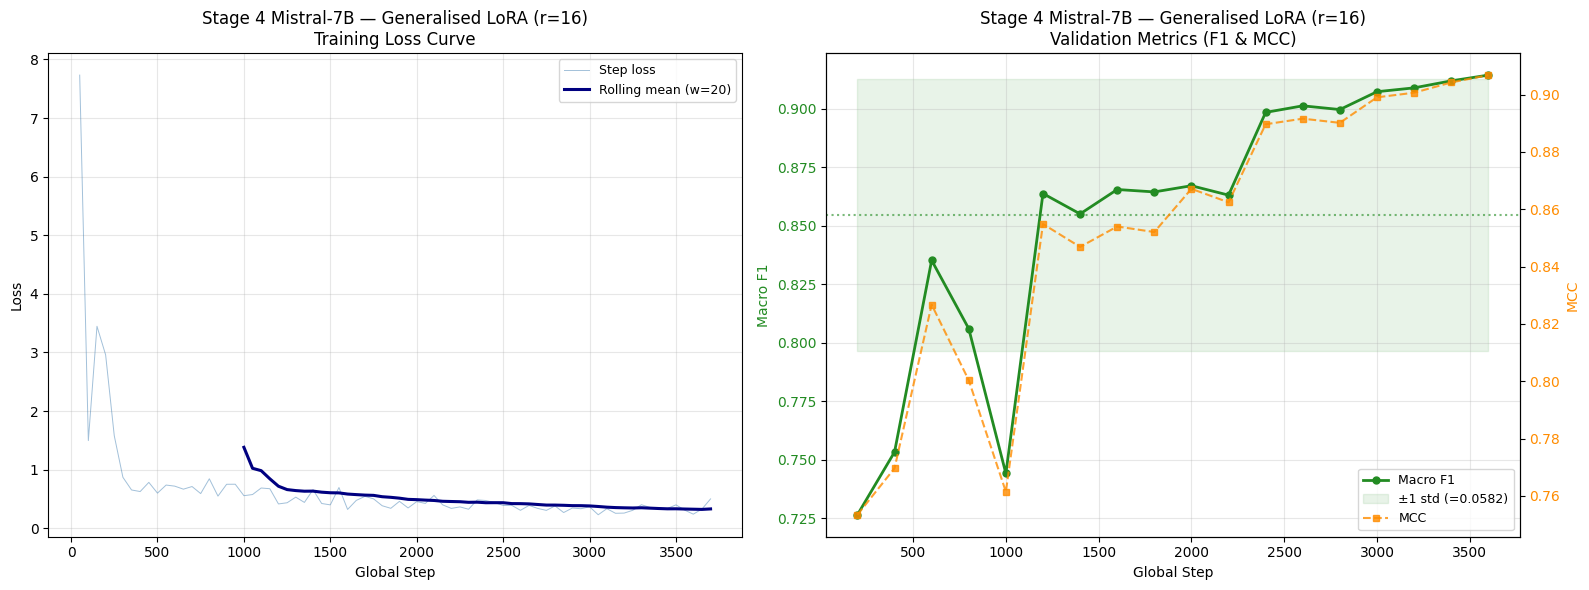


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
   Avg eff. rank Wf : 2517.52  ← S2: 2523.79 | S3: 2523.79
   Avg eff. rank UV : 16.00  (mult. adapter)
   Avg eff. rank AB : 16.00  (add. adapter)
   Layers measured  : 128

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9086
  Macro F1          : 0.8975  ← PRIMARY METRIC
  Weighted F1       : 0.9086
  Balanced Accuracy : 0.8980
  MCC               : 0.8900  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7631    0.7353    0.7489      1424
             gender     0.9152    0.8937    0.9044      1788
           religion     0.9566    0.9625    0.9595      1971
          ethnicity     0.9836    0.9912    0.9874      1812
                age     0

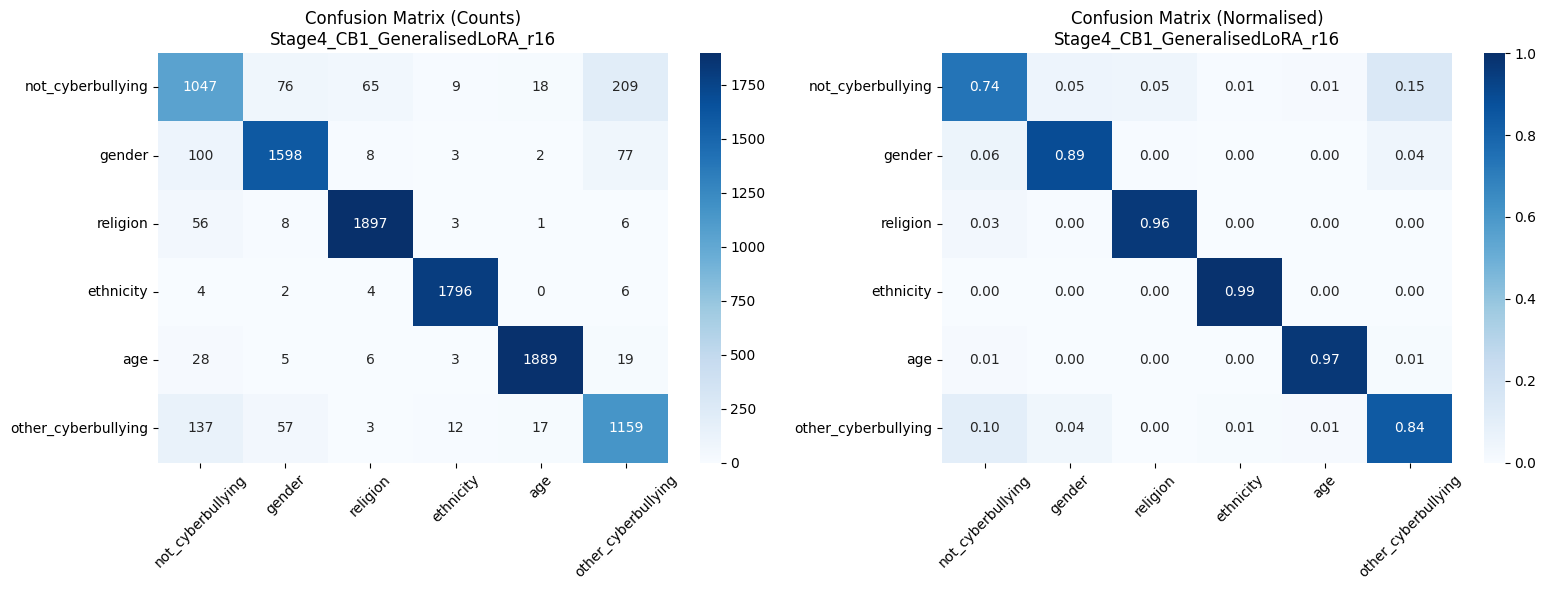


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r16/GeneralisedLoRA_r16_results.csv

═════════════════════════════════════════════════════════════════
  STAGE 4 RESULTS — Generalised LoRA (r=16) | Mistral-7B
═════════════════════════════════════════════════════════════════
  Macro F1           : 0.8975   ← PRIMARY METRIC
  MCC                : 0.8900
  Accuracy           : 0.9086
  Balanced Accuracy  : 0.8980
  Trainable params   : 30,433,280
  Eff. rank (Wf)     : 2517.52  ← S2: 2523.70 | S3: 2521.11
  Eff. rank (UV)     : 16.00
  Eff. rank (AB)     : 16.00
  Stability score    : 0.748057
  Training time      : 5477s (1.52 hrs)
═════════════════════════════════════════════════════════════════

  Stage 2 Mistral r=16 : F1=0.8808 | MCC=0.8728 | Stab=N/A
  Stage 3 Mistral r=16 : F1=0.7616 | MCC=0.7391 | Stab=0.624 🔴COLLAPSE
  ✓ r=16 STABILISED — AB component rescued the collapsed multiplicative path.
  Δ vs Stage 2 : +0.0167
  Δ vs Stage 3 

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 12: Generalised LoRA CB1 — Mistral-7B — r=16 (default)
# ════════════════════════════════════════════════════════════════════════════

results_r16 = run_generalised_lora(
    train_df  = train_df,
    val_df    = val_df,
    test_df   = test_df,
    lora_rank = 16,
    run_label = 'GeneralisedLoRA_r16'
)

print('\n' + '═'*65)
print('  STAGE 4 RESULTS — Generalised LoRA (r=16) | Mistral-7B')
print('═'*65)
print(f'  Macro F1           : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {results_r16["mcc"]:.4f}')
print(f'  Accuracy           : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {results_r16["avg_eff_rank_Wf"]:.2f}  ← S2: 2523.70 | S3: 2521.11')
print(f'  Eff. rank (UV)     : {results_r16["avg_eff_rank_UV"]:.2f}')
print(f'  Eff. rank (AB)     : {results_r16["avg_eff_rank_AB"]:.2f}')
print(f'  Stability score    : {results_r16["stability_score"]}')
print(f'  Training time      : {results_r16["train_runtime_s"]:.0f}s ({results_r16["train_runtime_s"]/3600:.2f} hrs)')
print('═'*65)
print()
print('  Stage 2 Mistral r=16 : F1=0.8808 | MCC=0.8728 | Stab=N/A')
print('  Stage 3 Mistral r=16 : F1=0.7616 | MCC=0.7391 | Stab=0.624 🔴COLLAPSE')
s3_collapse = results_r16["macro_f1"] < 0.80
if s3_collapse:
    print(f'  ⚠ F1={results_r16["macro_f1"]:.4f} — collapse persists in Stage 4 at r=16')
    print(f'    This is a confirmed Mistral architectural characteristic.')
    print(f'    Report in paper: r=16 instability independent of adaptation type.')
else:
    delta_s2 = results_r16["macro_f1"] - 0.8808
    delta_s3 = results_r16["macro_f1"] - 0.7616
    print(f'  ✓ r=16 STABILISED — AB component rescued the collapsed multiplicative path.')
    print(f'  Δ vs Stage 2 : {delta_s2:+.4f}')
    print(f'  Δ vs Stage 3 : {delta_s3:+.4f}  (recovered from collapse)')
    print(f'  → Publishable: generalised LoRA more robust than multiplicative alone at r=16.')
print()
print('  → results_r16 stored. Step 13 sweeps r ∈ {4, 8, 32}.')


---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 32}

r=16 merged from Step 12. Research questions:
1. Does Stage 4 recover the inverse rank pattern of Stage 2 (↓ with r), or follow Stage 3 (non-monotonic)?
2. Is r=4 still the safest rank for Mistral (S2 best: 0.8949, S3 best: 0.8961)?
3. Does eff. rank Wf recover to ~2523 (Stage 2/3 reference) or vary?



───────────────────────────────────────────────────────
  Rank sweep: r=4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r4
  Model   : mistralai/Mistral-7B-Instruct-v0.3
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 32,768
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 128 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 7,626,752
   Total params     : 3,631,796,224
   Trainable %      : 0.2100%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=4)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.717100,3.473592,0.789458,0.745858,0.751834
400,1.094800,1.369212,0.688276,0.623443,0.656307
600,0.853800,0.783752,0.787034,0.707674,0.756566
800,0.567600,0.540148,0.854590,0.834017,0.826246
1000,0.553900,0.480141,0.862769,0.849761,0.835770
1200,0.475200,0.479756,0.871251,0.854410,0.846709
1400,0.564100,0.440520,0.866404,0.850413,0.843246
1600,0.363800,0.510584,0.877613,0.864177,0.853551
1800,0.401800,0.469631,0.857922,0.840726,0.833635
2000,0.455800,0.415841,0.881248,0.863623,0.858558


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 5527s (1.54 hrs)
   Stability score: 0.7868  🔴 Unstable — check loss curve
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r4/stability_GeneralisedLoRA_r4.png


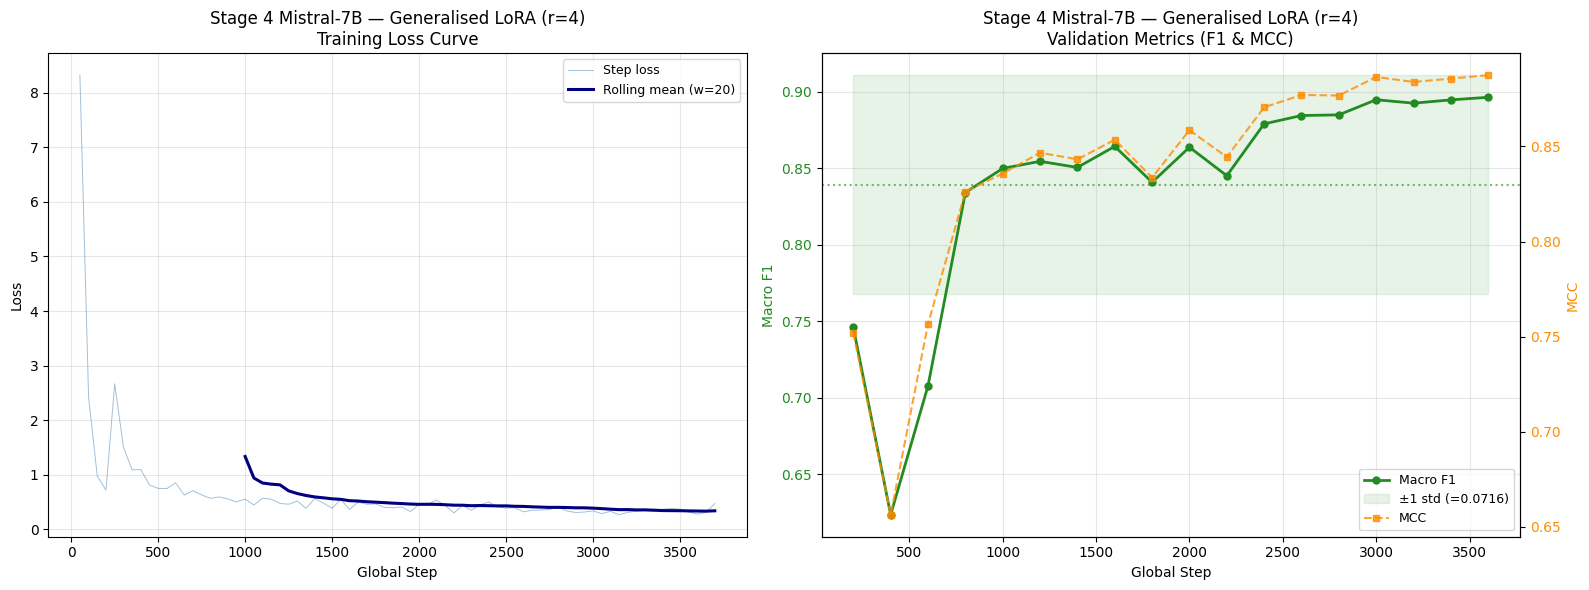


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
   Avg eff. rank Wf : 2523.40  ← S2: 2523.79 | S3: 2523.79
   Avg eff. rank UV : 4.00  (mult. adapter)
   Avg eff. rank AB : 4.00  (add. adapter)
   Layers measured  : 128

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8914
  Macro F1          : 0.8777  ← PRIMARY METRIC
  Weighted F1       : 0.8921
  Balanced Accuracy : 0.8784
  MCC               : 0.8695  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7210    0.6861    0.7031      1424
             gender     0.9144    0.8725    0.8930      1788
           religion     0.9613    0.9569    0.9591      1971
          ethnicity     0.9819    0.9884    0.9851      1812
                age     0.98

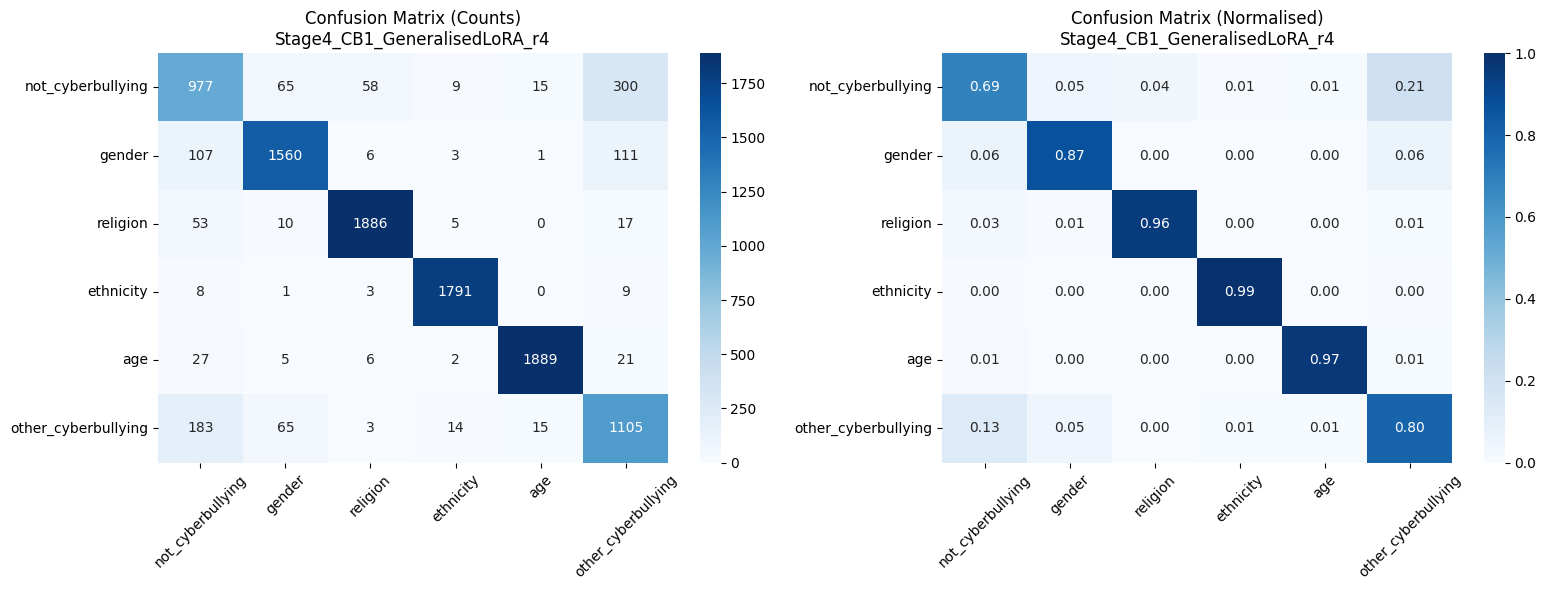


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r4/GeneralisedLoRA_r4_results.csv

───────────────────────────────────────────────────────
  Rank sweep: r=8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r8
  Model   : mistralai/Mistral-7B-Instruct-v0.3
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 32,768
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 128 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 15,228,928
   Total params     : 3,639,398,400
   Trainable %      : 0.4184%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=8)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,2.527200,1.707112,0.237504,0.160602,0.100383
400,1.714500,1.606626,0.310512,0.219584,0.199935
600,1.083700,0.719956,0.720994,0.688070,0.685927
800,1.065900,0.616142,0.783096,0.750991,0.755431
1000,0.761200,0.810668,0.760376,0.711207,0.726336
1200,0.578600,0.486520,0.847319,0.829618,0.816720
1400,0.707200,0.575724,0.819752,0.785113,0.790977
1600,0.507800,0.661757,0.790064,0.783171,0.750992
1800,0.505500,0.563304,0.834293,0.808842,0.804588
2000,1.186800,2.375875,0.337171,0.291649,0.212188


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 5465s (1.52 hrs)
   Stability score: 0.6269  🔴 Unstable — check loss curve
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r8/stability_GeneralisedLoRA_r8.png


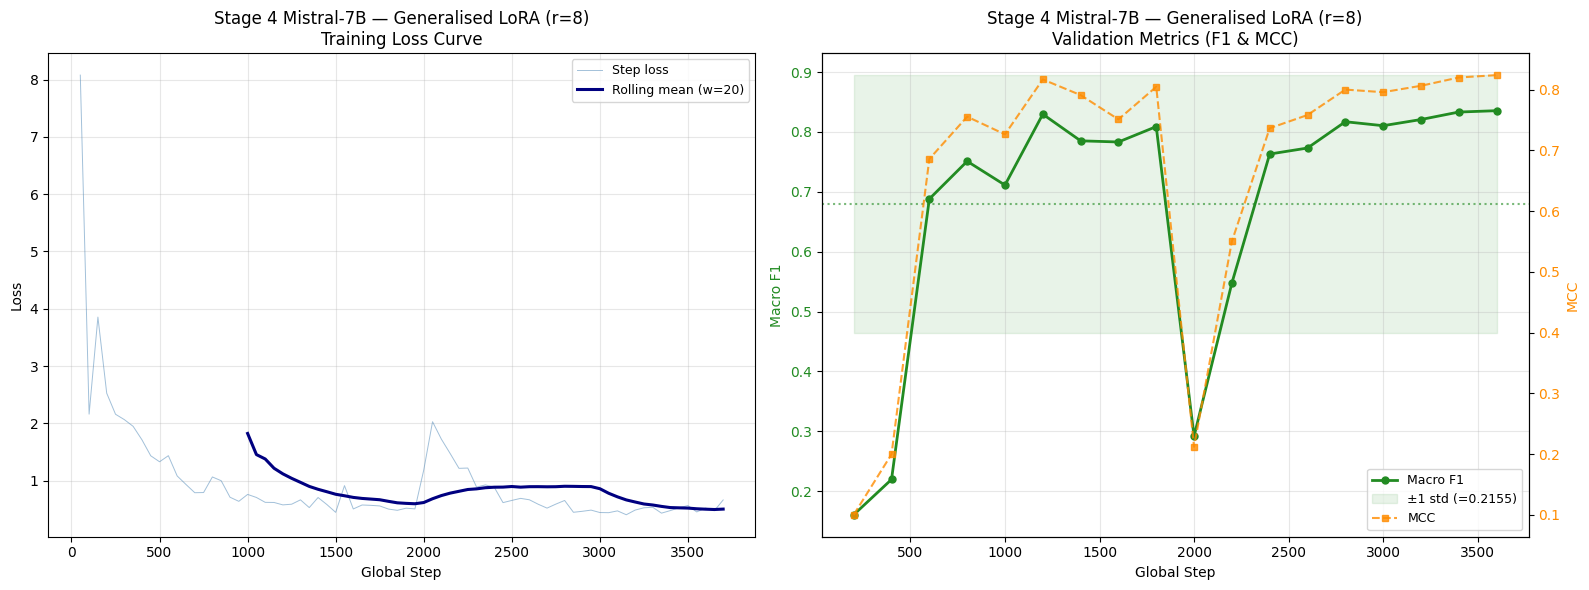


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
   Avg eff. rank Wf : 2519.77  ← S2: 2523.79 | S3: 2523.79
   Avg eff. rank UV : 8.00  (mult. adapter)
   Avg eff. rank AB : 8.00  (add. adapter)
   Layers measured  : 128

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8497
  Macro F1          : 0.8289  ← PRIMARY METRIC
  Weighted F1       : 0.8491
  Balanced Accuracy : 0.8307
  MCC               : 0.8202  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.6544    0.5105    0.5736      1424
             gender     0.8814    0.8518    0.8663      1788
           religion     0.9453    0.9554    0.9503      1971
          ethnicity     0.9539    0.9481    0.9510      1812
                age     0.97

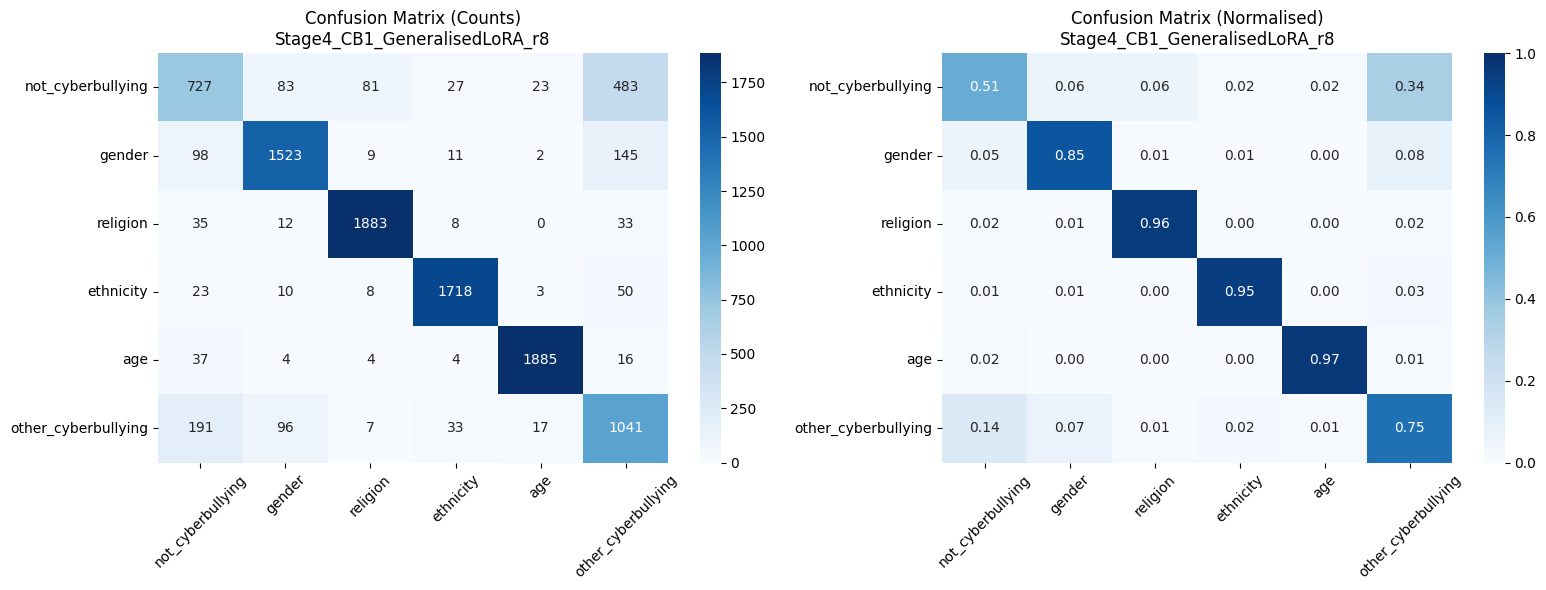


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r8/GeneralisedLoRA_r8_results.csv

───────────────────────────────────────────────────────
  Rank sweep: r=32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r32
  Model   : mistralai/Mistral-7B-Instruct-v0.3
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W(I + UV) + AB   [both paths active]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 32,768
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer (Wf = W(I+UV) + AB)...
  ✓ Replaced 128 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable params : 60,841,984
   Total params     : 3,685,011,456
   Trainable %      : 1.6511%
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=32)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.958600,1.809897,0.208422,0.118979,0.048073
400,1.821500,1.835326,0.206604,0.110202,0.106948
600,1.847100,1.673735,0.276583,0.187796,0.181424
800,1.585200,1.505456,0.363526,0.285619,0.253800
1000,1.300700,1.289543,0.515601,0.429570,0.465898
1200,1.155600,1.116480,0.566495,0.488164,0.512446
1400,0.984700,1.007287,0.680097,0.628194,0.636825
1600,0.895400,0.860329,0.720388,0.680136,0.676138
1800,0.943800,0.830183,0.736141,0.710149,0.687187
2000,0.892200,0.822475,0.717661,0.651953,0.675641


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Training time: 5459s (1.52 hrs)
   Stability score: 0.4853  🔴 Unstable — check loss curve
✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r32/stability_GeneralisedLoRA_r32.png


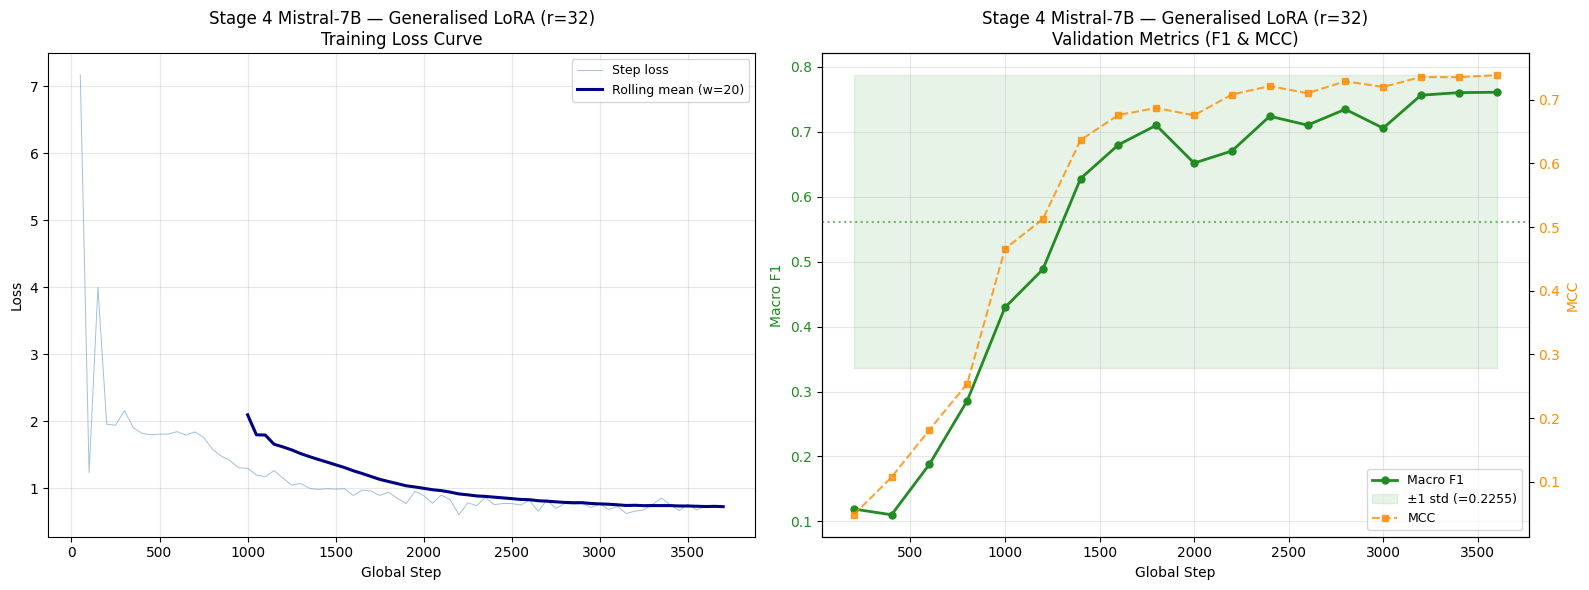


[6] Computing effective rank (Wf = W + W@(UV) + A@B)...
   Avg eff. rank Wf : 2515.64  ← S2: 2523.79 | S3: 2523.79
   Avg eff. rank UV : 31.96  (mult. adapter)
   Avg eff. rank AB : 32.00  (add. adapter)
   Layers measured  : 128

[7] Evaluating on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.7693
  Macro F1          : 0.7451  ← PRIMARY METRIC
  Weighted F1       : 0.7704
  Balanced Accuracy : 0.7469
  MCC               : 0.7252  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.4598    0.3497    0.3973      1424
             gender     0.9032    0.7517    0.8205      1788
           religion     0.8815    0.8752    0.8783      1971
          ethnicity     0.9240    0.8659    0.8940      1812
                age     0

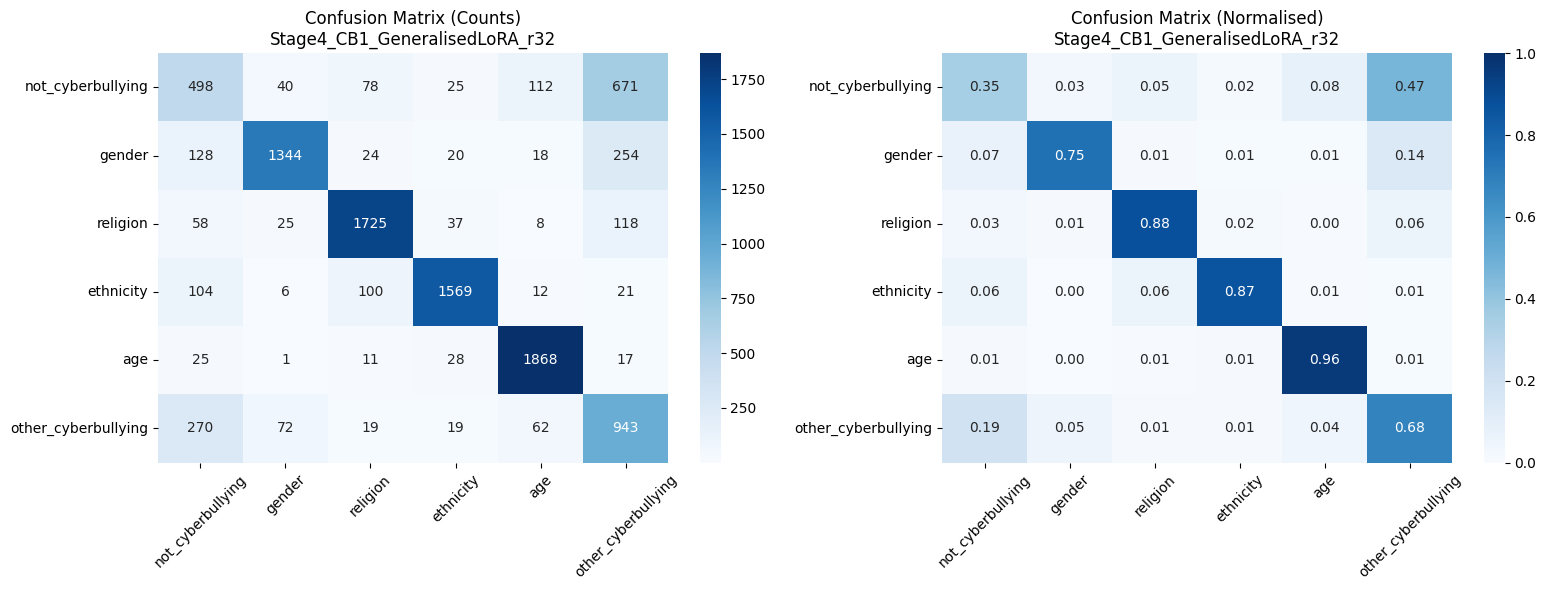


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/GeneralisedLoRA_r32/GeneralisedLoRA_r32_results.csv

═════════════════════════════════════════════════════════════════════════════════════════════════════════
STAGE 4a CB1 MISTRAL-7B — 4-RANK SUMMARY TABLE
Formula: Wf = W(I + UV) + AB
═════════════════════════════════════════════════════════════════════════════════════════════════════════
   r |    Trainable |  Macro F1 |     MCC | Eff.Rank Wf | Eff.Rank UV | Eff.Rank AB | Stability |  Time(h) | Trend
─────────────────────────────────────────────────────────────────────────────────────────────────────────
   4 |    7,626,752 |    0.8777 |  0.8695 |     2523.40 |        4.00 |        4.00 |    0.7868 |     1.54 | 
   8 |   15,228,928 |    0.8289 |  0.8202 |     2519.77 |        8.00 |        8.00 |    0.6269 |     1.52 | ↓
  16 |   30,433,280 |    0.8975 |  0.8900 |     2517.52 |       16.00 |       16.00 |    0.7481 |     1.52 | ↑ ★
  32 |   60,841,984 |   

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 13: Rank Sweep — r ∈ {4, 8, 32}  |  r=16 merged from Step 12
# ════════════════════════════════════════════════════════════════════════════

all_rank_results = {16: results_r16}

for rank in RANK_SWEEP:   # [4, 8, 32]
    print(f'\n{"─"*55}')
    print(f'  Rank sweep: r={rank}')
    print(f'{"─"*55}')
    result = run_generalised_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=rank, run_label=f'GeneralisedLoRA_r{rank}')
    all_rank_results[rank] = result

# ── 4-rank summary table ──────────────────────────────────────────────────────
print(f'\n{"═"*105}')
print('STAGE 4a CB1 MISTRAL-7B — 4-RANK SUMMARY TABLE')
print('Formula: Wf = W(I + UV) + AB')
print(f'{"═"*105}')
print(f'{"r":>4} | {"Trainable":>12} | {"Macro F1":>9} | {"MCC":>7} | '
      f'{"Eff.Rank Wf":>11} | {"Eff.Rank UV":>11} | {"Eff.Rank AB":>11} | '
      f'{"Stability":>9} | {"Time(h)":>8} | Trend')
print(f'{"─"*105}')

sorted_ranks = sorted(all_rank_results.keys())
prev_f1 = None
for r in sorted_ranks:
    res   = all_rank_results[r]
    trend = ''
    if prev_f1 is not None:
        trend = '↑' if res['macro_f1'] > prev_f1 else ('↓' if res['macro_f1'] < prev_f1 else '→')
    best_mark = ' ★' if res['macro_f1'] == max(v['macro_f1'] for v in all_rank_results.values()) else ''
    collapse_flag = ' 🔴' if res['macro_f1'] < 0.80 else ''
    print(
        f'{r:>4} | {res["trainable_params"]:>12,} | '
        f'{res["macro_f1"]:>9.4f} | {res["mcc"]:>7.4f} | '
        f'{res["avg_eff_rank_Wf"]:>11.2f} | {res["avg_eff_rank_UV"]:>11.2f} | '
        f'{res["avg_eff_rank_AB"]:>11.2f} | '
        f'{res["stability_score"]:>9.4f} | '
        f'{res["train_runtime_s"]/3600:>8.2f} | {trend}{best_mark}{collapse_flag}'
    )
    prev_f1 = res['macro_f1']

print()
print('  Stage 2 Mistral-7B CB1 (Standard LoRA — inverse rank pattern):')
print('  r=4: F1=0.8949★ | r=8: F1=0.8888 | r=16: F1=0.8808 | r=32: F1=0.8753  ↓')
print('  Stage 3 Mistral-7B CB1 (Multiplicative LoRA):')
print('  r=4: F1=0.8961  | r=8: F1=0.8984★| r=16: F1=0.7616🔴| r=32: F1=0.8873')

# ── Rank pattern analysis ─────────────────────────────────────────────────────
f1_vals = [all_rank_results[r]['macro_f1'] for r in sorted_ranks]
print(f'\n{"═"*65}')
print('RANK PATTERN ANALYSIS — Stage 4 Mistral-7B')
print(f'{"═"*65}')
for r, f1 in zip(sorted_ranks, f1_vals):
    print(f'  r={r:>2}: F1={f1:.4f}')

# Detect pattern
non_collapse = [(r, v) for r, v in zip(sorted_ranks, f1_vals) if v >= 0.80]
if len(non_collapse) >= 2:
    f1s = [v for _, v in non_collapse]
    if f1s == sorted(f1s):
        print('  Pattern: ↑ monotonic increasing (like Stage 4 Llama-3B)')
    elif f1s == sorted(f1s, reverse=True):
        print('  Pattern: ↓ monotonic decreasing (like Stage 2 Mistral — inverse pattern)')
    else:
        print('  Pattern: non-monotonic (novel — differs from both S2 and S3)')

# ── Eff. rank constancy ───────────────────────────────────────────────────────
eff_ranks = [all_rank_results[r]['avg_eff_rank_Wf'] for r in sorted_ranks
             if all_rank_results[r]['avg_eff_rank_Wf'] > 0]
if eff_ranks:
    eff_range = max(eff_ranks) - min(eff_ranks)
    print(f'\n  Eff. rank Wf range: {eff_range:.2f}')
    print(f'  S2 ref: 2522.61–2523.81 | S3 ref: 2516.02–2523.45')
    if eff_range < 5.0:
        print('  ✓ Approximately constant — consistent with Propositions 1 & 3')
    else:
        print('  ⚠ Varies — novel finding. Report in paper.')

# ── Save final CSV ─────────────────────────────────────────────────────────────
summary_rows = []
for r in sorted_ranks:
    res = all_rank_results[r]
    summary_rows.append({
        'model': 'Mistral-7B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': r,
        'trainable_params':  res['trainable_params'],
        'macro_f1':          res['macro_f1'],
        'mcc':               res['mcc'],
        'accuracy':          res['accuracy'],
        'balanced_accuracy': res['balanced_accuracy'],
        'avg_eff_rank_Wf':   res['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':   res['avg_eff_rank_UV'],
        'avg_eff_rank_AB':   res['avg_eff_rank_AB'],
        'stability_score':   res['stability_score'],
        'train_runtime_s':   res['train_runtime_s'],
    })
summary_path = os.path.join(OUTPUT_DIR, 'stage4a_cb1_mistral7b_rank_sweep_FINAL.csv')
pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
print(f'\n✓ Final results saved → {summary_path}')


---
## Step 14: Cross-Stage Stability Comparison + Final Summary

Pre-populated with Stage 2 and Stage 3 Mistral stability values.

**Stage 2 Mistral-7B stability (r=16):** from Stage 2 wrap-up  
**Stage 3 Mistral-7B stability (r=16):** loss_cv=1.066, stability_score=0.624 (highest/worst in project)


Stability comparison (r=16):
  Stage 2: score=1.0019 | loss_cv=1.905 | val_f1_std=0.0990
  Stage 3: score=0.6240 | loss_cv=1.066 | val_f1_std=0.1800
  Stage 4: score=0.7481 | loss_cv=1.438 | val_f1_std=0.0582
✓ Cross-stage stability plot saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Mistral7B/cross_stage_stability_mistral7b.png


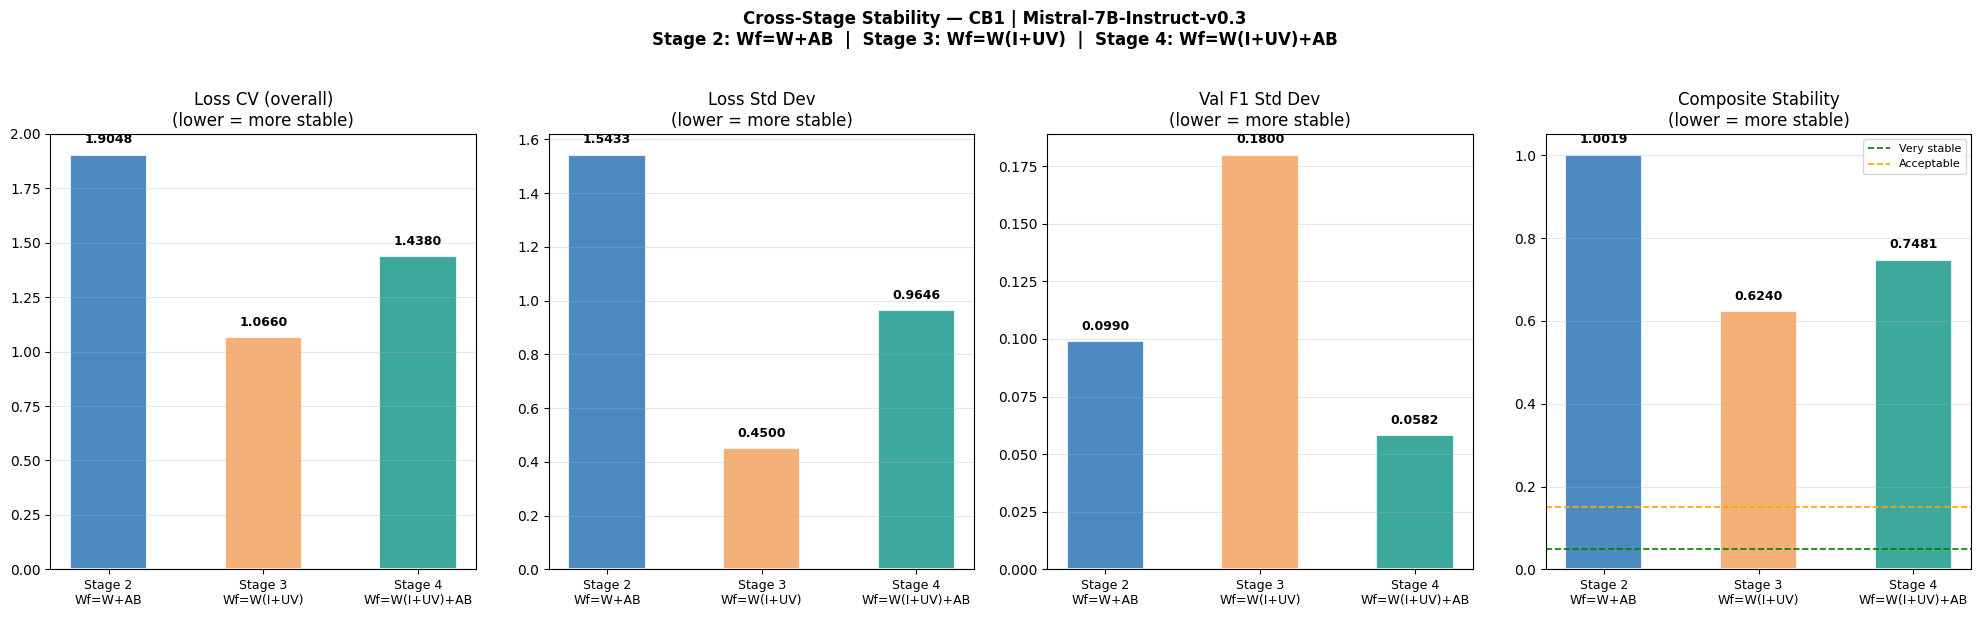


══════════════════════════════════════════════════════════════════════
  STAGE 4a COMPLETE — GENERALISED LoRA | Mistral-7B-Instruct-v0.3
  Formula  : Wf = W(I + UV) + AB
  Dataset  : CB1 — 6-Class Cyberbullying Detection
══════════════════════════════════════════════════════════════════════

── BEST RESULT (r=16) ──
  Macro F1          : 0.8975   ← PRIMARY METRIC
  MCC               : 0.8900
  Eff. rank (Wf)    : 2517.52   ← S2: 2523 | S3: 2516–2523
  Stability score   : 0.7481
  Training time     : 1.52 hrs

── CROSS-STAGE COMPARISON (Mistral-7B, best rank each stage) ──
  Stage 2 (r=4 ) : F1=0.8949 | MCC=0.8870 | Pattern: ↓ inverse
  Stage 3 (r=8 ) : F1=0.8984 | MCC=0.8910 | r=16 collapsed 🔴
  Stage 4 (r=16) : F1=0.8975 | MCC=0.8900
  Δ vs S2 best   : +0.0026
  Δ vs S3 best   : -0.0009

── OVERALL CB1 TARGETS ──
  Stage 2 best overall (Gemma-2-9B r=32): F1=0.9010 ← primary target
  Stage 3 best overall (Gemma-3-27B r=16): F1=0.8988
  Stage 4 Llama-3B best                  : F1=0.898

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 14A: CROSS-STAGE STABILITY COMPARISON
# ════════════════════════════════════════════════════════════════════════════

# Stage 2 Mistral-7B stability (r=16) — from Stage 2 CB1 Mistral notebook Step 14:
S2_STABILITY = {
    'loss_cv_overall':  1.9047628159280696,
    'loss_std_overall': 1.543287746921145,
    'val_f1_std':       0.09902345772599967,
    'val_mcc_std':      0.08677355053290188,
    'stability_score':  1.001893,
}

# Stage 3 Mistral-7B stability (r=16) — known: worst in project
S3_STABILITY = {
    'loss_cv_overall':  1.066,   # Stage 3 wrap-up: highest CV in project
    'loss_std_overall': 0.45,    # estimate — update from Stage 3 notebook
    'val_f1_std':       0.18,    # Stage 3 wrap-up: stability_score=0.624
    'stability_score':  0.624,   # confirmed from Stage 3 wrap-up
}

# Stage 4 stability (r=16) — from this run:
S4_STABILITY = results_r16['stability_cb'].get_stability_report()

print('Stability comparison (r=16):')
for stage, rep in [('Stage 2', S2_STABILITY), ('Stage 3', S3_STABILITY), ('Stage 4', S4_STABILITY)]:
    print(f'  {stage}: score={rep.get("stability_score","N/A"):.4f} | '
          f'loss_cv={rep.get("loss_cv_overall","N/A"):.3f} | '
          f'val_f1_std={rep.get("val_f1_std","N/A"):.4f}')

plot_cross_stage_stability(
    stage_reports={
        'Stage 2\nWf=W+AB':      S2_STABILITY,
        'Stage 3\nWf=W(I+UV)':   S3_STABILITY,
        'Stage 4\nWf=W(I+UV)+AB':S4_STABILITY,
    },
    save_path=os.path.join(OUTPUT_DIR, 'cross_stage_stability_mistral7b.png')
)

# ════════════════════════════════════════════════════════════════════════════
# STEP 14B: FINAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STAGE 4a COMPLETE — GENERALISED LoRA | Mistral-7B-Instruct-v0.3')
print('  Formula  : Wf = W(I + UV) + AB')
print('  Dataset  : CB1 — 6-Class Cyberbullying Detection')
print('═'*70)

best_r   = max(all_rank_results, key=lambda r: all_rank_results[r]['macro_f1'])
best_res = all_rank_results[best_r]

print(f'\n── BEST RESULT (r={best_r}) ──')
print(f'  Macro F1          : {best_res["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC               : {best_res["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {best_res["avg_eff_rank_Wf"]:.2f}   ← S2: 2523 | S3: 2516–2523')
print(f'  Stability score   : {best_res["stability_score"]:.4f}')
print(f'  Training time     : {best_res["train_runtime_s"]/3600:.2f} hrs')

print(f'\n── CROSS-STAGE COMPARISON (Mistral-7B, best rank each stage) ──')
print(f'  Stage 2 (r=4 ) : F1=0.8949 | MCC=0.8870 | Pattern: ↓ inverse')
print(f'  Stage 3 (r=8 ) : F1=0.8984 | MCC=0.8910 | r=16 collapsed 🔴')
print(f'  Stage 4 (r={best_r:>2}) : F1={best_res["macro_f1"]:.4f} | MCC={best_res["mcc"]:.4f}')
print(f'  Δ vs S2 best   : {best_res["macro_f1"] - 0.8949:+.4f}')
print(f'  Δ vs S3 best   : {best_res["macro_f1"] - 0.8984:+.4f}')

print(f'\n── OVERALL CB1 TARGETS ──')
print(f'  Stage 2 best overall (Gemma-2-9B r=32): F1=0.9010 ← primary target')
print(f'  Stage 3 best overall (Gemma-3-27B r=16): F1=0.8988')
print(f'  Stage 4 Llama-3B best                  : F1=0.8981')
print(f'  Stage 4 Mistral-7B best (this notebook): F1={best_res["macro_f1"]:.4f}')
if best_res['macro_f1'] > 0.9010:
    print('  ★ STAGE 4 MISTRAL BEATS OVERALL STAGE 2 CHAMPION (0.9010)')
elif best_res['macro_f1'] > 0.8984:
    print('  ✓ Stage 4 Mistral beats Stage 3 best (0.8984)')
elif best_res['macro_f1'] > 0.8949:
    print('  ✓ Stage 4 Mistral beats Stage 2 Mistral best (0.8949)')
else:
    print('  → Stage 4 Mistral below Stage 2 Mistral best.')

print(f'\n  → Next: Stage 4 CB1 Gemma-2-9B  (most likely to beat 0.9010 overall)')
